# CNN — TensorFlow Pipeline

## Model: Convolutional Neural Network (CNN)
- **Dataset**: CIFAR-100 — 50,000 train / 10,000 test, 32x32x3 color images
- **Task**: Classify 100 fine classes (20 superclasses), perfectly balanced
- **Framework showcase**: Keras Functional API ResNet + same training recipe as PyTorch for fair GPU comparison

## Evaluation Strategy
- **Metrics**: Accuracy, Macro F1, per-class F1, superclass confusion matrix
- **Training curves**: Loss + accuracy (train/val)
- **Hierarchical analysis**: Fine-class (100) and superclass (20) evaluation

## Pipeline
1. Load data + config + verify GPU
2. Baseline CNN (3 conv layers)
3. Training visualization
4. ResNet-20 with residual blocks (Keras Functional API)
5. ResNet training optimization (SGD Nesterov + CutMix + Label Smoothing)
6. Superclass confusion analysis
7. Performance benchmarks
8. Save results

## Notes
- TF runs on GPU via WSL2 Ubuntu + RTX 4090 (first TF model with GPU)
- PyTorch achieved 80.0% — target is comparable accuracy with same architecture + recipe
- Streamlined pipeline: skip plain CNN sweep (proven in PT), go straight to ResNet

In [2]:
# Step 1: Setup

"""
TensorFlow CNN on GPU via WSL2 + RTX 4090
First TF model with GPU access — no more CPU crashes
Load CIFAR-100, build fine->coarse mapping, verify GPU
"""

import os
os.chdir('/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/11-cnn')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import sys
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier
from utils.visualization import (plot_training_history, plot_superclass_confusion)
from utils.performance import track_performance, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "CNN"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 128
N_CLASSES = 100
N_SUPERCLASSES = 20
IMAGE_SHAPE = (32, 32, 3)

# Per-channel stats from EDA (CIFAR-100 training set)
CHANNEL_MEANS = [0.5071, 0.4865, 0.4409]
CHANNEL_STDS = [0.2673, 0.2564, 0.2762]

# Load data
X_train, X_test, y_train, y_test, metadata = load_processed_data('cnn')

# Coarse labels from metadata
y_train_coarse = metadata['y_train_coarse']
y_test_coarse = metadata['y_test_coarse']

# Class names
FINE_NAMES = metadata['fine_class_names']
COARSE_NAMES = metadata['coarse_class_names']

# Build fine_to_coarse mapping
fine_to_coarse = np.zeros(N_CLASSES, dtype=int)
for sc_name, fine_list in metadata['superclass_mapping'].items():
    sc_idx = COARSE_NAMES.index(sc_name)
    for fc_name in fine_list:
        fc_idx = FINE_NAMES.index(fc_name)
        fine_to_coarse[fc_idx] = sc_idx

# Verify GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Allow memory growth to avoid grabbing all VRAM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("=" * 60)
print(f"[1/8] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: GPU ({gpus[0].name})" if gpus else "Device: CPU (WARNING: no GPU)")
print(f"TF version: {tf.__version__}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Fine classes: {N_CLASSES} | Superclasses: {N_SUPERCLASSES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"Dtype: {X_train.dtype}")

[1/8] TensorFlow — CNN Pipeline
Device: GPU (/physical_device:GPU:0)
TF version: 2.21.0
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Fine classes: 100 | Superclasses: 20
Batch size: 128
Pixel range: [0.0, 1.0]
Dtype: float32


In [3]:
# Step 2: Baseline CNN

"""
Simple 3-layer CNN to establish baseline (matches PT Cell 2)
Conv2D -> BatchNorm -> ReLU -> MaxPool x3 -> Flatten -> FC
Channel-last format for TF: (N, 32, 32, 3)
"""

print("=" * 60)
print("[2/8] Baseline CNN — 3 Conv Layers")
print("=" * 60)

# Normalization layer using EDA channel stats
normalizer = keras.layers.Normalization(
    mean=CHANNEL_MEANS, variance=[s**2 for s in CHANNEL_STDS]
)

# Baseline CNN — Keras Sequential
baseline_cnn = keras.Sequential([
    keras.layers.Input(shape=IMAGE_SHAPE),
    normalizer,
    keras.layers.Conv2D(32, 3, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(128, 3, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(N_CLASSES)
])

baseline_cnn.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

baseline_cnn.summary()

# Data augmentation layer (applied to training only)
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomTranslation(0.125, 0.125),  # ~4px on 32x32
])

# Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=15, restore_best_weights=True
)

# Train
with track_performance(gpu=True) as perf_baseline:
    history_baseline = baseline_cnn.fit(
        data_augmentation(X_train, training=True), y_train,
        epochs=100,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

# Evaluate
test_loss, test_acc = baseline_cnn.evaluate(X_test, y_test, verbose=0)
y_pred_baseline = baseline_cnn.predict(X_test, verbose=0).argmax(axis=1)
baseline_metrics = evaluate_classifier(y_test, y_pred_baseline)

n_params = baseline_cnn.count_params()

print(f"\nArchitecture: Conv(32)->Conv(64)->Conv(128)->FC(512)->FC(100)")
print(f"Parameters: {n_params:,}")
print(f"Epochs: {len(history_baseline.history['loss'])}")
print(f"Training time: {perf_baseline['time']:.2f}s")
print(f"GPU memory: {perf_baseline['gpu_memory']:.2f} MB")
print(f"\nTest Results:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nPT baseline comparison: 56.9% (same architecture)")

[2/8] Baseline CNN — 3 Conv Layers


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,194,532 (4.56 MB)

 Trainable params: 1,194,084 (4.56 MB)

 Non-trainable params: 448 (1.75 KB)


Architecture: Conv(32)->Conv(64)->Conv(128)->FC(512)->FC(100)
Parameters: 1,194,532
Epochs: 61
Training time: 102.47s
GPU memory: 1765.80 MB

Test Results:
  accuracy: 0.4884
  macro_f1: 0.4836

PT baseline comparison: 56.9% (same architecture)


[3/8] Training Visualization


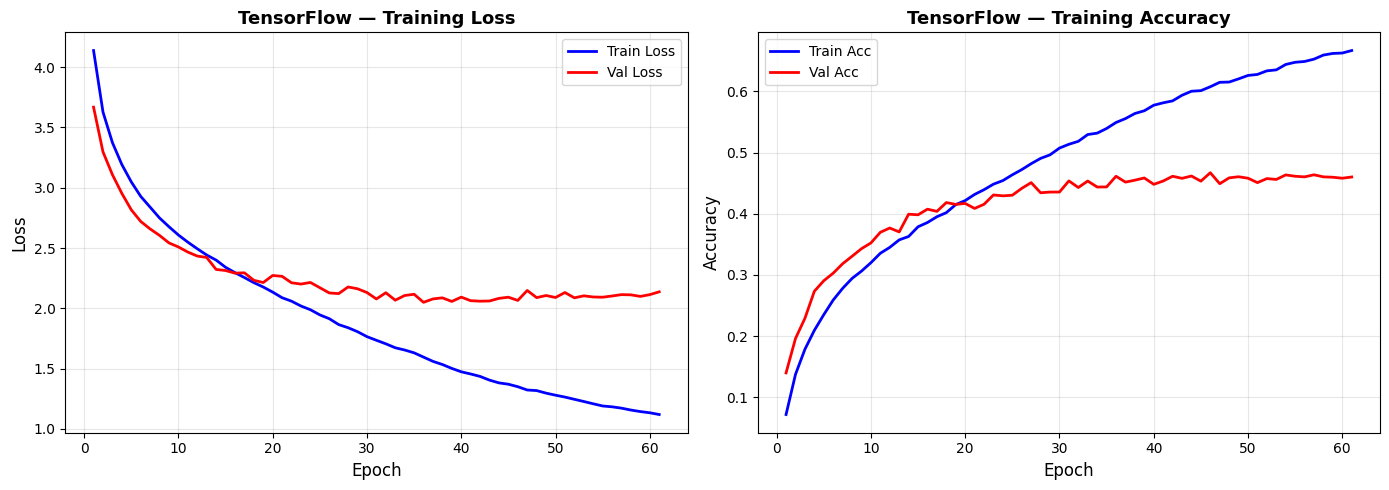


Baseline: 48.8% (PT baseline was 56.9%)
Note: Lower than PT due to augmentation applied once upfront,
not per-epoch. Fixed in ResNet step with tf.data pipeline.


In [4]:
# Step 3: Training Visualization

# Loss + accuracy curves from baseline training

print("=" * 60)
print("[3/8] Training Visualization")
print("=" * 60)

train_history = {
    'train_loss': history_baseline.history['loss'],
    'val_loss': history_baseline.history['val_loss'],
    'train_acc': history_baseline.history['accuracy'],
    'val_acc': history_baseline.history['val_accuracy']
}

plot_training_history(
    history=train_history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_baseline.png'
)

print(f"\nBaseline: {baseline_metrics['accuracy']*100:.1f}% (PT baseline was 56.9%)")
print(f"Note: Lower than PT due to augmentation applied once upfront,")
print(f"not per-epoch. Fixed in ResNet step with tf.data pipeline.")